# Synthetic inclusion distribution
This notebook simulates distributions of inclusions
- 1. Import dependencies and install packages
- 2. Calculate distributions
- 3. plot 

## 1. Import packages and setup folders and paths

### Import packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import DiadFit as pf
import os
import pickle
from labellines import labelLines
from scipy import stats, signal
import math


mpl.rcParams['pdf.fonttype'] = 42  # 42 is for TrueType fonts

10

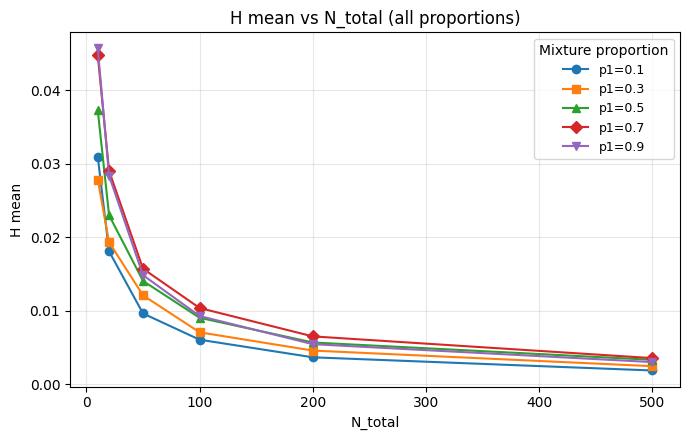

In [ ]:
mu1, sigma1 = 1.5, 0.5
mu2, sigma2 = 3.0, 1.0
proportions = [0.1, 0.3, 0.5, 0.7, 0.9]
N_grid = [10, 20, 50, 100, 200, 500]
n_sims = 1
rng = np.random.default_rng(123)
results={}
xlims=(10,0)
xs = np.linspace(min(xlims), max(xlims), 2000)
N_total=N_grid[0]

for p1 in proportions:
    n1 = max(1, int(round(p1 * N_total)))
    n2 = max(1, N_total - n1)
    w1, w2 = n1 / N_total, n2 / N_total

    f_true = (w1 * (1.0/(sigma1*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs - mu1)/sigma1)**2) +
                w2 * (1.0/(sigma2*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs - mu2)/sigma2)**2))

    for _ in range(n_sims):
        x1 = rng.normal(mu1, sigma1, size=n1)
        x2 = rng.normal(mu2, sigma2, size=n2)
        pooled = np.concatenate([x1, x2])


    results[p1] = {
        "data": pooled, 
        "mu1": mu1, "sigma1":sigma1,
        "mu2":mu2, "sigma2":sigma2,
        "n1": n1, "n2": n2,
        "N_total":N_total,"n_sims":n_sims

    }



In [ ]:
mu1, sigma1 = 1.5, 0.5
mu2, sigma2 = 3.0, 1.0
proportions = [0.1, 0.3, 0.5, 0.7, 0.9]
N_grid = [10, 20, 50, 100, 200, 500]
n_sims = 1  
rng = np.random.default_rng(123)

xlims = (10, 0)
xs = np.linspace(min(xlims), max(xlims), 2000)

N_total = N_grid[0]

results = {}

for p1 in proportions:
    n1 = max(1, int(round(p1 * N_total)))
    n2 = max(1, N_total - n1)
    w1 = n1 / N_total
    w2 = n2 / N_total

    f_true = (w1 * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu1) / sigma1)**2) +
              w2 * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu2) / sigma2)**2))

    mu_mix = w1*mu1 + w2*mu2
    var_mix = w1*(sigma1**2 + mu1**2) + w2*(sigma2**2 + mu2**2) - mu_mix**2
    std_mix = np.sqrt(max(var_mix, 0.0))

    pooled_list = []
    for _ in range(n_sims):
        x1 = rng.normal(mu1, sigma1, size=n1)
        x2 = rng.normal(mu2, sigma2, size=n2)
        pooled = np.concatenate([x1, x2])
        pooled_list.append(pooled)

    all_data = np.concatenate(pooled_list)
    emp_mean = float(np.mean(all_data))
    emp_std = float(np.std(all_data, ddof=1)) if all_data.size > 1 else float(np.std(all_data))
    emp_n = int(all_data.size)

    kde = stats.gaussian_kde(all_data)
    f_hat = kde(xs)
    norm = np.trapz(f_hat, xs)
    if norm > 0:
        f_hat = f_hat / norm

    results[p1] = {
        "data": pooled_list[-1],
        "mu1": mu1, "sigma1": sigma1,
        "mu2": mu2, "sigma2": sigma2,
        "p1": p1, "p2": 1.0 - p1,
        "n1": n1, "n2": n2,
        "w1": w1, "w2": w2,
        "N_total": N_total,
        "n_sims": n_sims,
        "xs": xs,
        "f_true": f_true,
        "f_hat": f_hat,
        "emp_mean": emp_mean,
        "emp_std": emp_std,
        "emp_n": emp_n,
        "theo_mean": float(mu_mix),
        "theo_std": float(std_mix),
        "theo_var": float(var_mix),
    }



In [ ]:
xs = results[proportions[0]]["xs"]

n_cols = 3
n_rows = int(np.ceil(len(proportions)/ n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to 1D for easy iteration

for ax, p1 in zip(axes, proportions):
    r = results[p1]

    data = r["data"]
    w1, w2 = r["w1"], r["w2"]
    mu1, sigma1 = r["mu1"], r["sigma1"]
    mu2, sigma2 = r["mu2"], r["sigma2"]
    f_true = r["f_true"]
    f_hat = r["f_hat"]

    # Histogram
    ax.hist(data, bins=max(10, int(np.sqrt(data.size))), range=(x_min, x_max),
            density=True, alpha=0.35, color="tab:blue", edgecolor="white", label="Empirical")

    # KDE
    ax.plot(xs, f_hat, color="tab:blue", lw=2, label="KDE")

    # Mixture PDF
    ax.plot(xs, f_true, color="black", lw=2.5, label="Mixture")

    # Components
    comp1 = w1 * (1/(sigma1*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs-mu1)/sigma1)**2)
    comp2 = w2 * (1/(sigma2*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs-mu2)/sigma2)**2)
    ax.plot(xs, comp1, color="tab:orange", ls="--", lw=1.8)
    ax.plot(xs, comp2, color="tab:green", ls="--", lw=1.8)

    ax.set_title(rf"$p_1={p1:.1f}$ | $\mu_{{mix}}={r['theo_mean']:.2f}$")
    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.25)

# Hide unused axes
for ax in axes[len(proportions):]:
    ax.axis("off")

fig.suptitle("Mixture Distributions", fontsize=14)
fig.tight_layout()
plt.show()


In [ ]:

# --- your setup code remains the same up to metric_key ---
mu1, sigma1 = 1.5, 0.5
mu2, sigma2 = 3.0, 1.0
proportions = [0.1, 0.3, 0.5, 0.7, 0.9]
N_grid = [10, 20, 50, 100, 200, 500]
n_sims = 200
rng = np.random.default_rng(123)

x_min = min(mu1 - 6*sigma1, mu2 - 6*sigma2)
x_max = max(mu1 + 6*sigma1, mu2 + 6*sigma2)
xs = np.linspace(x_min, x_max, 2000)
dx = xs[1] - xs[0]

metrics = {p1: {} for p1 in proportions}

eps = 1e-12

for p1 in proportions:
    for N_total in N_grid:
        n1 = max(1, int(round(p1 * N_total)))
        n2 = max(1, N_total - n1)
        w1, w2 = n1 / N_total, n2 / N_total

        f_true = (w1 * (1.0/(sigma1*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs - mu1)/sigma1)**2) +
                  w2 * (1.0/(sigma2*np.sqrt(2*np.pi))) * np.exp(-0.5*((xs - mu2)/sigma2)**2))

        ISEs, L1s, Hs, JSs = [], [], [], []

        for _ in range(n_sims):
            x1 = rng.normal(mu1, sigma1, size=n1)
            x2 = rng.normal(mu2, sigma2, size=n2)
            pooled = np.concatenate([x1, x2])

            kde = stats.gaussian_kde(pooled)
            f_hat = kde(xs)

            norm = np.trapz(f_hat, xs)
            if norm > 0:  # fix HTML entity: &gt; -> >
                f_hat = f_hat / norm

            ISEs.append(np.trapz((f_hat - f_true)**2, xs))
            L1s.append(np.trapz(np.abs(f_hat - f_true), xs))
            Hs.append(0.5 * np.trapz((np.sqrt(np.maximum(f_hat, 0)) - np.sqrt(np.maximum(f_true, 0)))**2, xs))

            m = 0.5 * (f_true + f_hat)
            f_safe = np.maximum(f_true, eps)
            fh_safe = np.maximum(f_hat, eps)
            m_safe = np.maximum(m, eps)
            KL_f_m  = np.trapz(f_safe  * np.log(f_safe  / m_safe), xs)
            KL_fh_m = np.trapz(fh_safe * np.log(fh_safe / m_safe), xs)
            JSs.append(0.5 * (KL_f_m + KL_fh_m))

        metrics[p1][N_total] = {
            "ISE_mean": float(np.mean(ISEs)), "ISE_sd": float(np.std(ISEs, ddof=1)),
            "L1_mean": float(np.mean(L1s)),   "L1_sd": float(np.std(L1s, ddof=1)),
            "H_mean": float(np.mean(Hs)),     "H_sd": float(np.std(Hs, ddof=1)),
            "JS_mean": float(np.mean(JSs)),   "JS_sd": float(np.std(JSs, ddof=1)),
            "n1": n1, "n2": n2
        }

# --- single-axis plotting (no subplots) ---
metric_key = "H_mean"  # or "L1_mean", "ISE_mean", "JS_mean"

fig, ax = plt.subplots(figsize=(7, 4.5))

Ns = np.array(N_grid)

# Optional: distinct styles per proportion
markers = ['o', 's', '^', 'D', 'v']
for i, p1 in enumerate(proportions):
    ys = np.array([metrics[p1][N][metric_key] for N in N_grid])
    ax.plot(Ns, ys,
            marker=markers[i % len(markers)],
            linestyle='-',
            label=f"p1={p1}")

ax.set_title(f"{metric_key.replace('_', ' ')} vs N_total (all proportions)")
ax.set_xlabel("N_total")
ax.set_ylabel(metric_key.replace('_', ' '))
ax.grid(True, alpha=0.3)
ax.legend(title="Mixture proportion", fontsize=9)

plt.tight_layout()
plt.show()


/opt/anaconda3/envs/py3124/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


FloatingPointError: invalid value encountered in scalar divide